In [10]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_no_proteins import CNNModel
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib
import torch
from torch.utils.data import DataLoader, TensorDataset


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT id, value,fractions, boundaries, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]

train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.5).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()


batch_sz = 512

def build_X(rows):
    return np.concatenate([
        np.array(rows['value'].tolist(),      dtype=np.float32),  # (n, 300)
        np.array(rows['fractions'].tolist(),  dtype=np.float32),  # (n, 6)
        np.array(rows['boundaries'].tolist(), dtype=np.float32),  # (n, 12)
    ], axis=1)

X_train = build_X(train_rows)
X_val   = build_X(val_rows)
X_test  = build_X(test_rows)

y_train = torch.tensor(np.array(train_rows['label'].values, dtype=np.int64))
y_val   = torch.tensor(np.array(val_rows['label'].values,   dtype=np.int64))
y_test  = torch.tensor(np.array(test_rows['label'].values,  dtype=np.int64))

X_train, X_val, X_test = map(torch.tensor, [X_train, X_val, X_test])

train_dl = DataLoader(TensorDataset(X_train, y_train, torch.tensor(train_rows['id'].to_numpy())), batch_size=batch_sz, shuffle=True)
val_dl   = DataLoader(TensorDataset(X_val,   y_val,   torch.tensor(val_rows['id'].to_numpy())),   batch_size=batch_sz)
test_dl  = DataLoader(TensorDataset(X_test,  y_test,  torch.tensor(test_rows['id'].to_numpy())),  batch_size=batch_sz)

CNN.retrain(train_dl,val_dl,patience=15)

Antal utan m-komponent i träningsdatan: 30492
Antal med m-komponent i träningsdatan: 4730
Epoch   0 | train: 3.8089 | val: 0.6222 | acc: 82.56% | AUC: 0.651
  -> ny bästa modell sparad till ../models/convolution_model_no_proteins.pth
Epoch   1 | train: 0.6387 | val: 0.6400 | acc: 63.94% | AUC: 0.698
Epoch   2 | train: 0.6070 | val: 0.5550 | acc: 89.42% | AUC: 0.725
  -> ny bästa modell sparad till ../models/convolution_model_no_proteins.pth
Epoch   3 | train: 0.5876 | val: 0.4990 | acc: 92.62% | AUC: 0.776
  -> ny bästa modell sparad till ../models/convolution_model_no_proteins.pth
Epoch   4 | train: 0.5546 | val: 0.4845 | acc: 93.20% | AUC: 0.790
  -> ny bästa modell sparad till ../models/convolution_model_no_proteins.pth
Epoch   5 | train: 0.5224 | val: 0.5533 | acc: 75.35% | AUC: 0.829
Epoch   6 | train: 0.5036 | val: 0.4350 | acc: 91.78% | AUC: 0.876
  -> ny bästa modell sparad till ../models/convolution_model_no_proteins.pth
Epoch   7 | train: 0.4592 | val: 0.4072 | acc: 88.90% | 

              precision    recall  f1-score   support

     Negativ       0.99      0.97      0.98      7146
     Positiv       0.73      0.92      0.81       586

    accuracy                           0.97      7732
   macro avg       0.86      0.94      0.90      7732
weighted avg       0.97      0.97      0.97      7732

[[6943  203]
 [  48  538]]
AUC: 0.9856130879204958
Accuracy:  96.75%
FN-rate:   8.19%  (farliga missade fall)
FP-rate:   2.84%  (onödiga larm)
Sensitivitet:   91.81%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   97.16%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9856


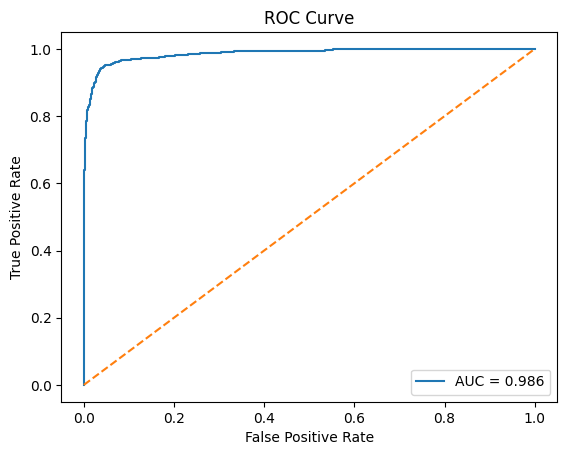

In [11]:
test_rows = test_rows[test_rows['label'].isin([0,1])]
result = CNN.predict(test_rows)
_ = evaluate(result,threshold=0.5,proportion=70)